
# Lab 6: FEM 1D - SEBASTIAN MENA TORRES

### Exercise 1: Use FEM 1D to solve the EDO

Use FEM to solve the next EDO (improve the code seen in class). Compare with the analytical solution for some N elements.

\begin{equation}
-\dfrac{d^2y}{dx^2}=xe^x\,,\text{with}\; y(0)=(3-e)  \;, y(1)=0
\end{equation}


* Build a general scrip to solve a PDE of order two with Dirichlet's conditions: $y(a), y(b), x\,\epsilon\, [a,b]$. Use the method seen in class.

Nota: Solving the Green's function for this particular case we are able to find the analytical solution:
\begin{equation}
y(x) = 1-e-e^x(x-2)-x
\end{equation}

## 1. Resolución EDO usando FEM 1D

In [2]:
import numpy as np
import matplotlib.pyplot as plt


def FEM(N, f, xa, xb, ya, yb):
    """
    Resuelve la EDO de segundo orden: 
    con condiciones de Dirichlet:
    usando el Método de Elementos Finitos (FEM 1D).
    """
    # Discretización del dominio
    x = np.linspace(xa, xb, N + 1)
    h = (xb - xa) / N
    
    # Ensamblaje de la Matriz de Rigidez A 
    # Se crea una matriz tridiagonal: 2/h en la diagonal, -1/h en las adyacentes
    diag_principal = np.ones(N + 1) * (2.0 / h)
    diag_adyacente = np.ones(N) * (-1.0 / h)
    A = np.diag(diag_principal) + np.diag(diag_adyacente, k=1) + np.diag(diag_adyacente, k=-1)
    
    # Vector de carga b
    b = h * f(x)
    
    # Aplicación de las condiciones de frontera (Dirichlet)
    A[0, :] = 0; A[0, 0] = 1; b[0] = ya
    A[-1, :] = 0; A[-1, -1] = 1; b[-1] = yb
    
    # Resolución del sistema lineal
    u = np.linalg.solve(A, b)
    
    return x, u



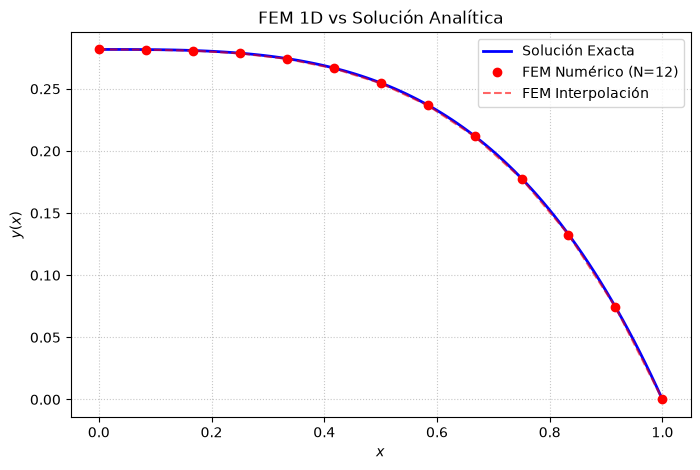

In [3]:
# Solución analítica conocida
def exact(x):
    return 1 - np.e - np.exp(x)*(x - 2) - x

# Función de forzamiento (lado derecho de la EDO)
def g(x):
    return x * np.exp(x)

# Condiciones iniciales y de frontera
xa, xb = 0.0, 1.0
ya, yb = 3.0 - np.e, 0.0
N = 12  # Número de elementos


# Ejecutar solución FEM
x_int, y_int = FEM(N, g, xa, xb, ya, yb)

# Interpolación para una curva suave
x_new = np.linspace(xa, xb, 100)
y_new = np.interp(x_new, x_int, y_int)

# Gráfica comparativa
plt.figure(figsize=(8, 5))
plt.plot(x_new, exact(x_new), 'b-', linewidth=2, label='Solución Exacta')
plt.plot(x_int, y_int, 'ro', markersize=6, label=f'FEM Numérico (N={N})')
plt.plot(x_new, y_new, 'r--', alpha=0.6, label='FEM Interpolación')

plt.title("FEM 1D vs Solución Analítica")
plt.xlabel(r'$x$')
plt.ylabel(r'$y(x)$')
plt.legend(loc='best')
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

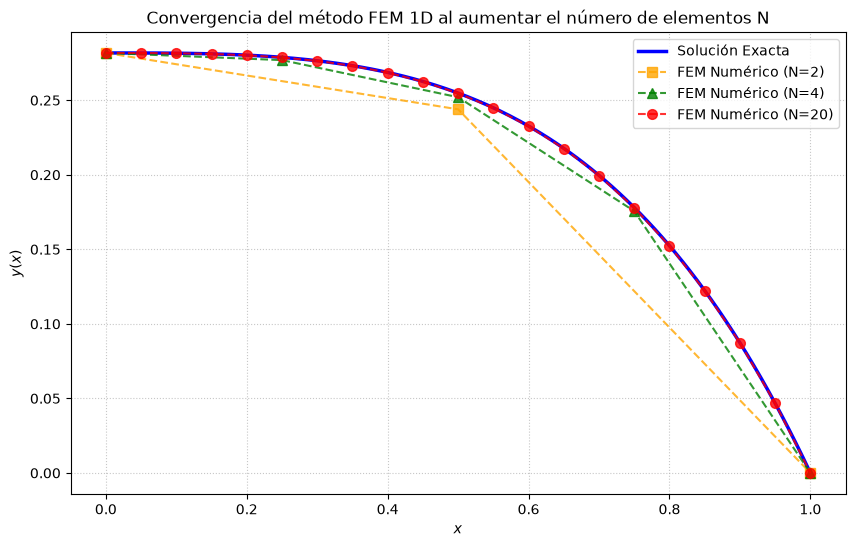

In [ ]:
# COMPARACIÓN DE LA SOLUCIÓN VARIANDO EL NÚMERO DE ELEMENTOS (N)


# Lista de valores N a evaluar
N_values = [2, 4, 20]

# Listas de estilos para diferenciar cada curva en la gráfica
colores = ['orange', 'green', 'red']
marcadores = ['s', '^', 'o'] 

plt.figure(figsize=(10, 6))

# 1. Graficar la solución analítica exacta (línea base)
x_dense = np.linspace(xa, xb, 200) 
plt.plot(x_dense, exact(x_dense), 'b-', linewidth=2.5, label='Solución Exacta')

# 2. Ciclo for para calcular y graficar FEM para cada valor de N
for N_actual, color, marcador in zip(N_values, colores, marcadores):
    # Calcular solución numérica
    x_num, y_num = FEM(N_actual, g, xa, xb, ya, yb)
    
    # Graficar puntos y líneas punteadas
    plt.plot(x_num, y_num, color=color, marker=marcador, linestyle='--', 
             alpha=0.8, markersize=7, label=f'FEM Numérico (N={N_actual})')

# Configuración visual de la gráfica
plt.title("Convergencia del método FEM 1D al aumentar el número de elementos N")
plt.xlabel(r'$x$')
plt.ylabel(r'$y(x)$')
plt.legend(loc='best')
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()